In [5]:
from sklearn.datasets import  make_regression
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.model_selection import cross_val_score

In [6]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

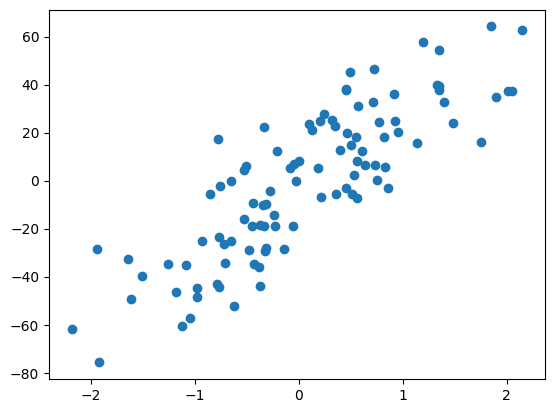

In [7]:
plt.scatter(X,y)

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(X_train,y_train)
print(lr.coef_)              # coef is Slope 
print(lr.intercept_)        # intercept is b

[28.12597332]
-2.2710144261783825


In [12]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
print('R2 score:', r2_score(y_test, y_pred))

R2 score: 0.6345158782661012


## Mathematical Formulation

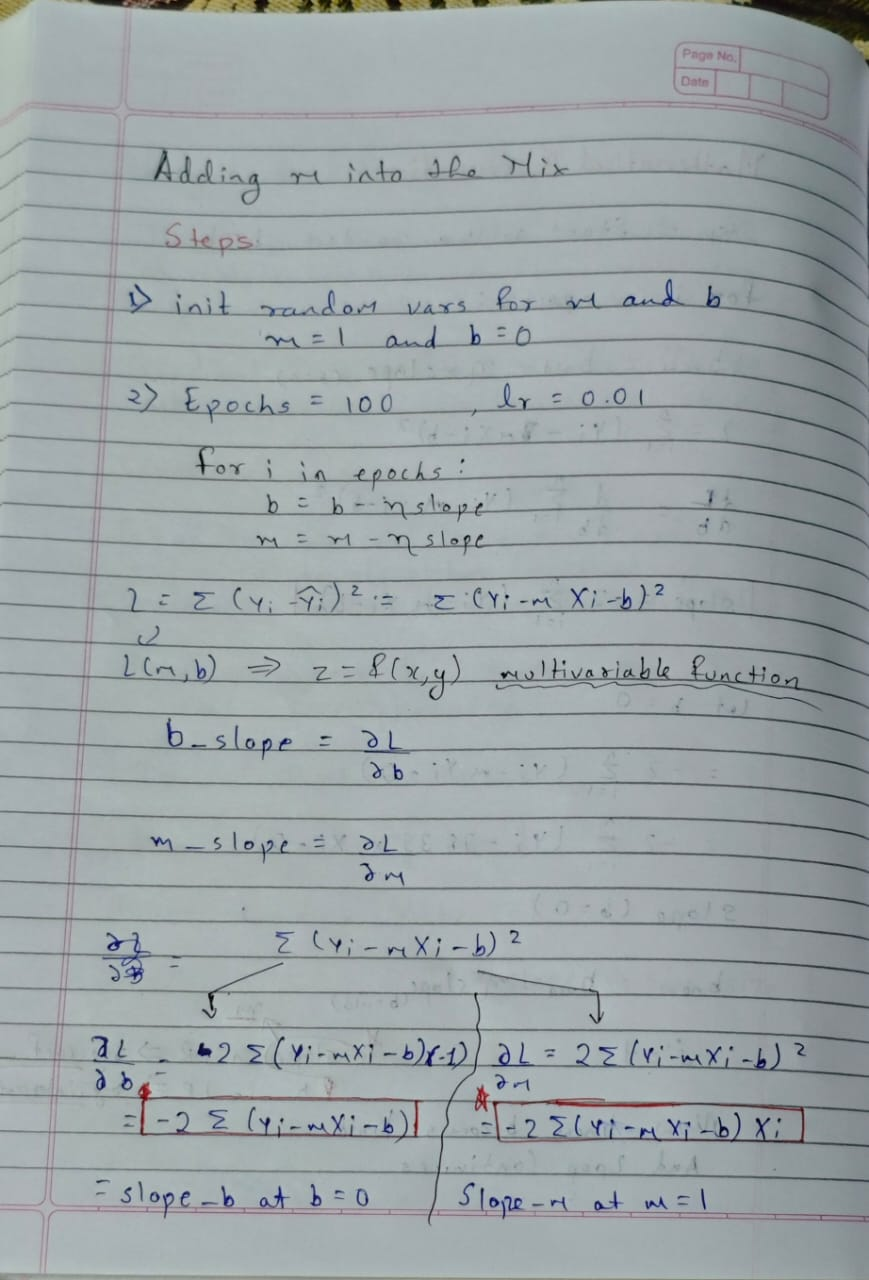

In [16]:
class GDRegressor:
    def __init__(self, learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):

        #Calculate the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m * X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m * X.ravel() - self.b) * X.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)

        print('m:', self.m)
        print('b:', self.b)

    def predict(self,X):
        return self.m * X + self.b
        

In [17]:
gd = GDRegressor(learning_rate=0.001, epochs=50)

In [18]:
gd.fit(X_train,y_train)

m: 28.159367347119066
b: -2.3004574196824854


In [19]:
y_pred = gd.predict(X_test)
print('R2 score:', r2_score(y_test, y_pred))

R2 score: 0.6343842836315579
